# Calls exploration

Starter scaffold for poking at the call DataFrames.

If you haven't already, run `python scripts/cache_calls_to_parquet.py` once to convert the CSVs to parquet — this notebook expects the parquet cache to exist.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARQUET_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Data/parquet_cache")

In [6]:
FIGURES_DIR = Path("/Users/gilyginosar/Dropbox (Personal)/Vocalizations_project/Figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.pdf", bbox_inches="tight")


In [7]:
# Shared analysis settings — change here, every plotting cell picks them up.
N = 10  # minutes per bin
LIGHT_DEFAULT = (8, 20)
LIGHT_OVERRIDES = {"2026_02": (4, 16)}


## What's available?

In [2]:
sorted(p.name for p in PARQUET_DIR.glob("*.parquet"))

['all_calls_2024_12.parquet',
 'all_calls_2025_03.parquet',
 'all_calls_2025_07.parquet',
 'all_calls_2025_10.parquet',
 'all_calls_2026_02.parquet']

## Load one month

Each row is one call. To work with several months at once, load each parquet with `pd.read_parquet(...)` and concatenate them with `pd.concat([...], ignore_index=True)`.

In [8]:
df = pd.read_parquet(PARQUET_DIR / "all_calls_2025_10.parquet")
df.head()

,exp,file_num,event_type,start_time_file_sec,stop_time_file_sec,duration_sec,assigned_location,channel,meanprob_noise,meanprob_alarm,meanprob_high_freq,meanprob_newborn,meanprob_stacks,meanprob_warble,start_time_experiment_sec,stop_time_experiment_sec,start_time_real,stop_time_real,date_folder,day_in_experiment
0,332,0,stacks,91.660416,91.913208,0.252792,underground,30,0.024811,0.034895,0.008730,0.001708,0.849352,0.005861,91.660416,91.913208,2025-10-06 15:07:59.660416,2025-10-06 15:07:59.913208,2025_10,1
1,332,0,stacks,92.018816,92.141816,0.123000,underground,30,0.112390,0.025191,0.009005,0.001420,0.784741,0.007076,92.018816,92.141816,2025-10-06 15:08:00.018816,2025-10-06 15:08:00.141816,2025_10,1
2,332,0,stacks,93.361408,93.478392,0.116984,underground,30,0.010942,0.019514,0.007465,0.001593,0.876718,0.006235,93.361408,93.478392,2025-10-06 15:08:01.361408,2025-10-06 15:08:01.478392,2025_10,1
3,332,0,stacks,96.020992,96.129528,0.108536,underground,30,0.073119,0.025917,0.008601,0.001729,0.792288,0.008054,96.020992,96.129528,2025-10-06 15:08:04.020992,2025-10-06 15:08:04.129528,2025_10,1
4,332,0,stacks,97.794048,97.970424,0.176376,underground,30,0.065315,0.016790,0.007076,0.000701,0.808000,0.005571,97.794048,97.970424,2025-10-06 15:08:05.794048,2025-10-06 15:08:05.970424,2025_10,1


## Shape and dtypes

In [10]:
print(df.shape)
df.info()

(894036, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 894036 entries, 0 to 894035
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   exp                        894036 non-null  int64         
 1   file_num                   894036 non-null  int64         
 2   event_type                 894036 non-null  object        
 3   start_time_file_sec        894036 non-null  float64       
 4   stop_time_file_sec         894036 non-null  float64       
 5   duration_sec               894036 non-null  float64       
 6   assigned_location          894036 non-null  object        
 7   channel                    894036 non-null  int64         
 8   meanprob_noise             894036 non-null  float64       
 9   meanprob_alarm             894036 non-null  float64       
 10  meanprob_high_freq         894036 non-null  float64       
 11  meanprob_newborn           894036 non-n

## A first cut: how many of each call type?

## Your turn

A few directions you might try next — pick one and we'll work through it together:

- How many calls per experiment? (`df.groupby("exp")...`)
- What's the distribution of call types within each location (`assigned_location`)?
- Calls per hour-of-day. (`df["start_time_real"].dt.hour`)
- Mean call duration per call type.
- ...

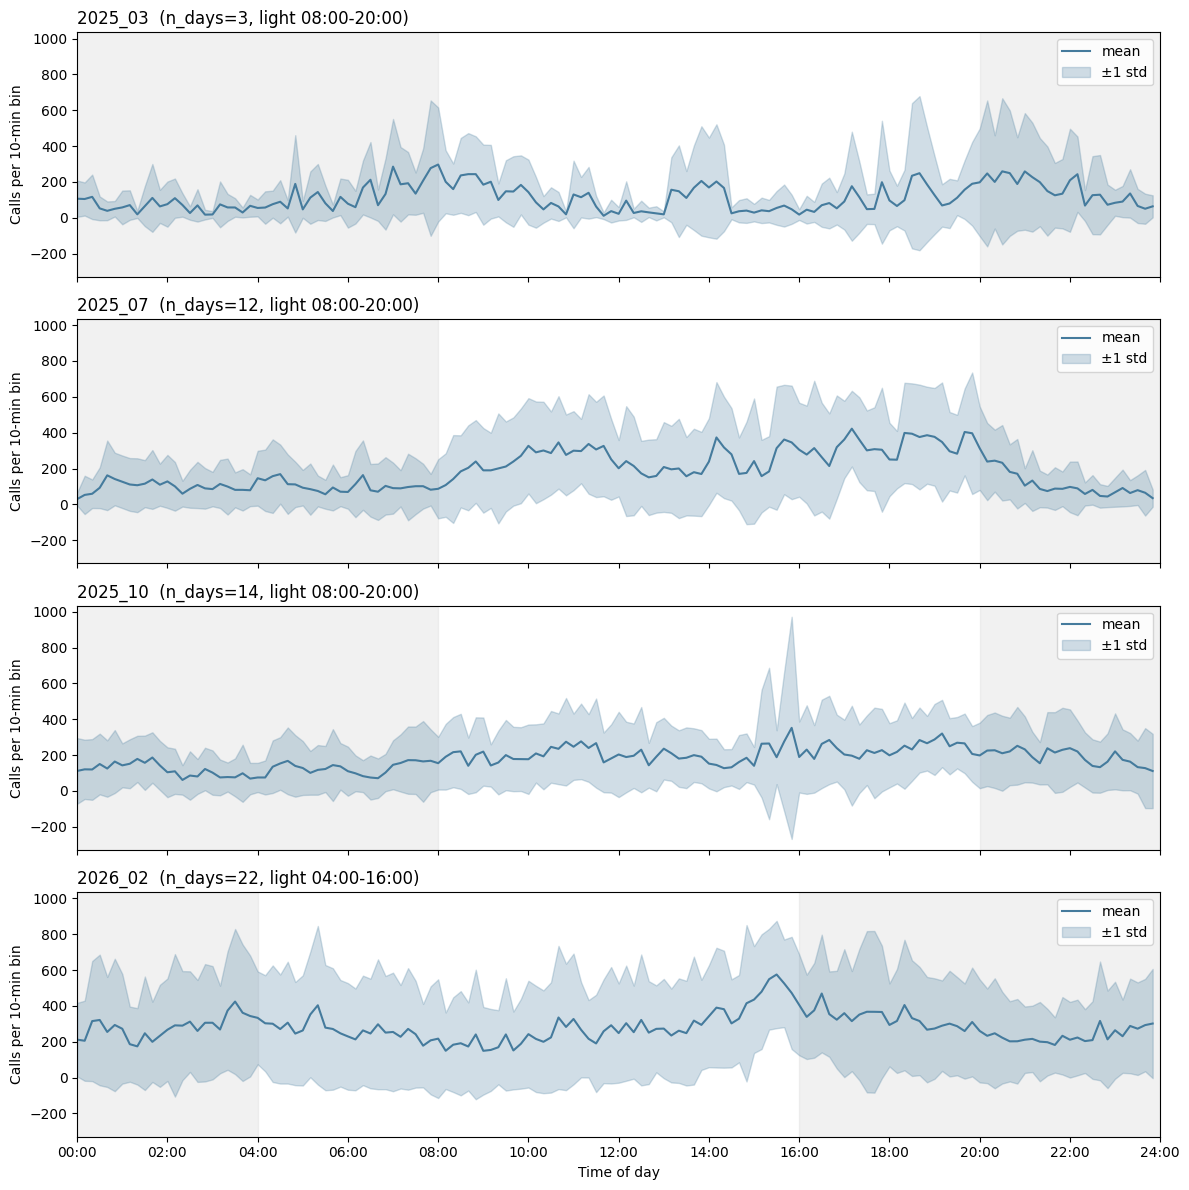

In [ ]:
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

fig, axes = plt.subplots(
    len(DATES_TO_PLOT), 1,
    figsize=(12, 3 * len(DATES_TO_PLOT)),
    sharex=True,
    sharey=True,
)

for ax, date_tag in zip(axes, DATES_TO_PLOT):
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    ts = df_d["start_time_real"]
    day = ts.dt.normalize()
    slot = ((ts.dt.hour * 60 + ts.dt.minute) // N) * N

    counts = df_d.groupby([day, slot]).size()
    matrix = counts.unstack(fill_value=0)
    mean = matrix.mean(axis=0)
    std  = matrix.std(axis=0)

    x_hours = mean.index / 60
    ax.plot(x_hours, mean, color="#457B9D", label="mean")
    ax.fill_between(x_hours, mean - std, mean + std, alpha=0.25, color="#457B9D", label="±1 std")

    # Dark hours background — pick this date's light window, fall back to default.
    light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
    if light_start < light_end:
        ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
        ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
    else:
        ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

    ax.set_title(f"{date_tag}  (n_days={matrix.shape[0]}, light {light_start:02d}:00-{light_end:02d}:00)", loc="left")
    ax.set_ylabel(f"Calls per {N}-min bin")
    ax.set_xlim(0, 24)
    ax.legend(loc="upper right")

# X-axis labels (only on the bottom subplot since sharex=True).
ticks = range(0, 25, 2)
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f"{h:02d}:00" for h in ticks])
axes[-1].set_xlabel("Time of day")

fig.tight_layout()
plt.show()
save_fig(fig, "calls_per_bin_4dates")


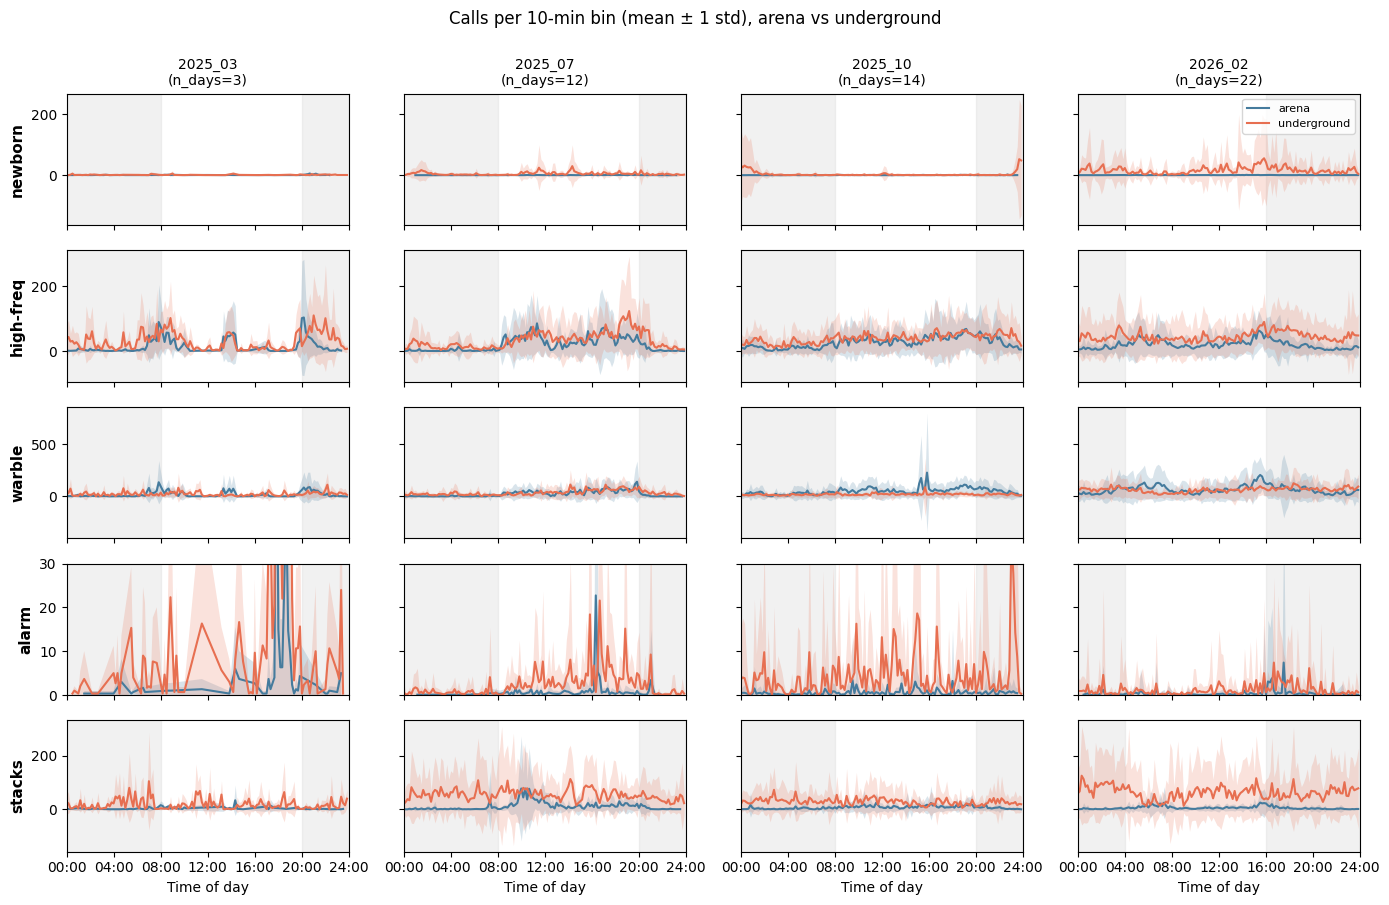

In [5]:
# 5x4 grid (call types x dates), with 2 lines per panel: arena vs underground.
DATES_TO_PLOT = ["2025_03", "2025_07", "2025_10", "2026_02"]

CALL_TYPE_ORDER = ["newborn", "high-freq", "warble", "alarm", "stacks"]
LOCATION_ORDER  = ["arena", "underground"]
loc_colors = {"arena": "#457B9D", "underground": "#E76F51"}

# Pre-compute per-date mean/std as MultiIndex Series indexed by
# (slot, event_type, assigned_location).
curves = {}
n_days_by_date = {}
for date_tag in DATES_TO_PLOT:
    df_d = pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet")
    ts = df_d["start_time_real"]
    day  = ts.dt.normalize().rename("day")
    slot = (((ts.dt.hour * 60 + ts.dt.minute) // N) * N).rename("slot")
    location = df_d["assigned_location"].replace({"arena_1": "arena", "arena_2": "arena"})

    # Group on FOUR keys at once. The result is a Series with a 4-level
    # MultiIndex: (day, slot, event_type, assigned_location).
    counts = df_d.groupby([day, slot, df_d["event_type"], location]).size()

    # Pivot the `day` level out to columns so we can collapse across days.
    # `fill_value=0` is critical — a missing day means zero calls there, not NaN.
    pivot = counts.unstack(level="day", fill_value=0)
    mean = pivot.mean(axis=1)   # rows: (slot, event_type, assigned_location)
    std  = pivot.std(axis=1)

    curves[date_tag] = (mean, std)
    n_days_by_date[date_tag] = pivot.shape[1]

fig, axes = plt.subplots(
    len(CALL_TYPE_ORDER), len(DATES_TO_PLOT),
    figsize=(3.5 * len(DATES_TO_PLOT), 1.8 * len(CALL_TYPE_ORDER)),
    sharex=True,
    sharey="row",   # each call-type row gets its own y-scale
)

for r, ct in enumerate(CALL_TYPE_ORDER):
    for c, date_tag in enumerate(DATES_TO_PLOT):
        ax = axes[r, c]
        mean, std = curves[date_tag]

        for loc in LOCATION_ORDER:
            try:
                # .xs() pulls out a slice along given index levels, leaving the
                # other levels intact. Here we drop event_type and assigned_location,
                # leaving a Series indexed by slot — exactly what we plot.
                m_l = mean.xs((ct, loc), level=("event_type", "assigned_location"))
                s_l = std.xs((ct, loc),  level=("event_type", "assigned_location"))
            except KeyError:
                continue  # this (call_type, location) combo had no calls in this date

            x_hours = m_l.index / 60
            ax.plot(x_hours, m_l, label=loc, color=loc_colors[loc])
            ax.fill_between(x_hours, m_l - s_l, m_l + s_l,
                            alpha=0.2, color=loc_colors[loc], linewidth=0)

        # Dark-hours background.
        light_start, light_end = LIGHT_OVERRIDES.get(date_tag, LIGHT_DEFAULT)
        if light_start < light_end:
            ax.axvspan(0, light_start, color="lightgray", alpha=0.3, zorder=0)
            ax.axvspan(light_end, 24, color="lightgray", alpha=0.3, zorder=0)
        else:
            ax.axvspan(light_end, light_start, color="lightgray", alpha=0.3, zorder=0)

        if r == 0:
            ax.set_title(f"{date_tag}\n(n_days={n_days_by_date[date_tag]})", fontsize=10)
        if c == 0:
            ax.set_ylabel(ct, fontsize=11, fontweight="bold")
        ax.set_xlim(0, 24)

# Legend on the top-right panel only — same colors apply everywhere.
axes[0, -1].legend(loc="upper right", fontsize=8)

ticks = range(0, 25, 4)
for ax in axes[-1]:
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{h:02d}:00" for h in ticks])
    ax.set_xlabel("Time of day")

axes[3, 0].set_ylim(0, 30)   # only the "alarm" row, all 4 dates

fig.suptitle(f"Calls per {N}-min bin (mean ± 1 std), arena vs underground", y=1.0, fontsize=12)
fig.tight_layout()
plt.show()
save_fig(fig, "grid_calltype_x_date_arena_vs_underground")


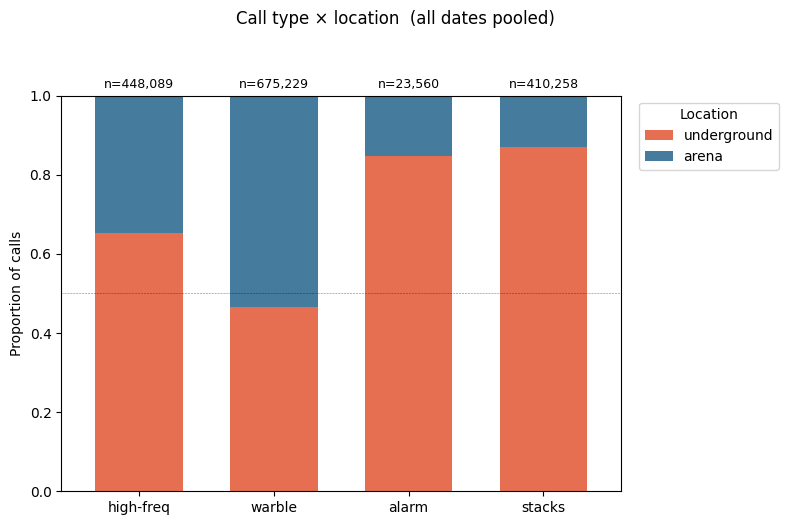

In [17]:
CALL_TYPE_ORDER = ["high-freq", "warble", "alarm", "stacks"]
LOCATION_ORDER  = ["underground", "arena"]      # underground first → goes at the bottom
LOC_COLORS      = ["#E76F51", "#457B9D"]        # match LOCATION_ORDER

df_all = pd.concat(
    [pd.read_parquet(PARQUET_DIR / f"all_calls_{d}.parquet") for d in DATES_TO_PLOT],
    ignore_index=True,
)
df_all["location"] = df_all["assigned_location"].replace(
    {"arena_1": "arena", "arena_2": "arena"}
)

props = (
    df_all.groupby(["event_type", "location"])
    .size()
    .unstack(fill_value=0)
    .reindex(CALL_TYPE_ORDER, fill_value=0)
    [LOCATION_ORDER]
)
totals = props.sum(axis=1)
props = props.div(totals, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
props.plot.bar(stacked=True, ax=ax, color=LOC_COLORS, width=0.65)

ax.set_ylabel("Proportion of calls")
ax.set_xlabel("")
ax.set_xticklabels(CALL_TYPE_ORDER, rotation=0)
ax.set_ylim(0, 1)
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.4, alpha=0.5)
ax.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")

# n_calls annotations above each bar.
for i, n in enumerate(totals):
    ax.text(i, 1.02, f"n={int(n):,}", ha="center", fontsize=9)

# Title placed higher so it doesn't overlap the n= annotations.
fig.suptitle("Call type × location  (all dates pooled)", y=1.04, fontsize=12)

fig.tight_layout()
save_fig(fig, "call_type_location_pooled")
plt.show()


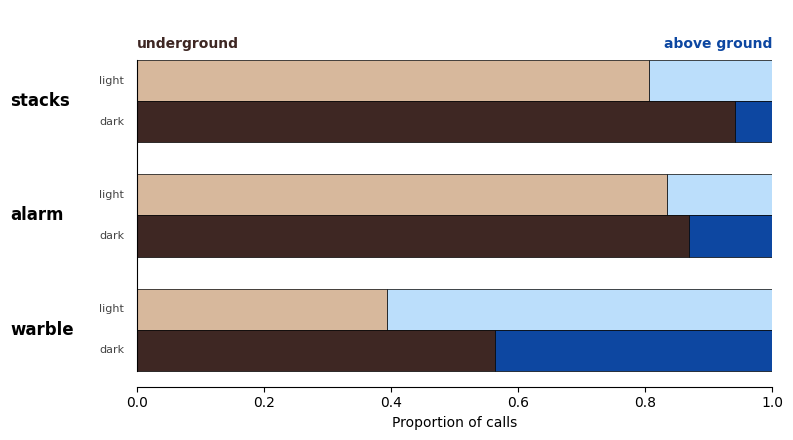

In [ ]:
# Horizontal stacked bars per call type, ordered bottom-to-top: warble, stacks, alarm.
# (high-freq dropped per request.)
# Each call type has two bars (light, dark). Each bar sums to 1 within that
# period; underground sits on the left, above-ground stacked to its right.
# Color palette: earth-tone underground (browns), sky-tone above (blues).

CALL_TYPES = ["alarm", "stacks","warble"]   # bottom to top

COLORS = {
    ("underground", "light"): "#D7B89C",   # pale tan
    ("underground", "dark"):  "#3E2723",   # deep brown
    ("above",       "light"): "#BBDEFB",   # pale sky blue
    ("above",       "dark"):  "#0D47A1",   # deep navy
}

# Load all dates.
parts = []
for date_tag in DATES_TO_PLOT:
    parts.append(pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet"))
all_calls = pd.concat(parts, ignore_index=True)

all_calls["loc_2"] = all_calls["assigned_location"].map(LOC_GROUPS)

light_starts = all_calls["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[0])
light_ends   = all_calls["date_folder"].map(lambda d: LIGHT_OVERRIDES.get(d, LIGHT_DEFAULT)[1])
hours = all_calls["start_time_real"].dt.hour
is_light = np.where(
    light_starts < light_ends,
    (hours >= light_starts) & (hours < light_ends),
    (hours >= light_starts) | (hours <  light_ends),
)
all_calls["light_dark"] = np.where(is_light, "light", "dark")


def compute_2x2(call_type):
    """2x2 col-normalized: rows [above, underground] x cols [light, dark]."""
    sub = all_calls[all_calls["event_type"] == call_type]
    counts = pd.crosstab(sub["loc_2"], sub["light_dark"]).reindex(
        index=["arena", "underground"], columns=["light", "dark"], fill_value=0
    )
    arr = counts.values.astype(float)
    col_sums = arr.sum(axis=0, keepdims=True)
    return np.divide(arr, col_sums, out=np.zeros_like(arr), where=col_sums > 0)


fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(CALL_TYPES))
height = 0.36

for i, ct in enumerate(CALL_TYPES):
    m = compute_2x2(ct)   # rows: [above, underground], cols: [light, dark]
    above_light, above_dark = m[0, 0], m[0, 1]
    under_light, under_dark = m[1, 0], m[1, 1]

    # Light bar (top of pair, lighter shades).
    y_light = y[i] + height/2
    ax.barh(y_light, under_light, height,
            color=COLORS[("underground", "light")], edgecolor="black", linewidth=0.5)
    ax.barh(y_light, above_light, height, left=under_light,
            color=COLORS[("above", "light")], edgecolor="black", linewidth=0.5)

    # Dark bar (bottom of pair, darker shades).
    y_dark = y[i] - height/2
    ax.barh(y_dark, under_dark, height,
            color=COLORS[("underground", "dark")], edgecolor="black", linewidth=0.5)
    ax.barh(y_dark, above_dark, height, left=under_dark,
            color=COLORS[("above", "dark")], edgecolor="black", linewidth=0.5)

    # Period sublabels just left of the y-axis.
    ax.text(-0.02, y_light, "light", ha="right", va="center", fontsize=8, color="#444")
    ax.text(-0.02, y_dark,  "dark",  ha="right", va="center", fontsize=8, color="#444")

ax.set_yticks(y)
ax.set_yticklabels([""] * len(CALL_TYPES))   # hide defaults; we add custom left-aligned text
ax.tick_params(axis="y", which="major", left=False, pad=0)

# Left-aligned call type labels (axes-x coords so all three line up).
for i, ct in enumerate(CALL_TYPES):
    ax.text(-0.20, y[i], ct, ha="left", va="center",
            fontsize=12, fontweight="bold",
            transform=ax.get_yaxis_transform())
ax.set_xlabel("Proportion of calls")
ax.set_xlim(0, 1.0)
ax.set_ylim(-0.5, len(CALL_TYPES) - 0.5 + 0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Clip the left spine to the bar region only (no extension up to the labels).
ax.spines["left"].set_bounds(-height, len(CALL_TYPES) - 1 + height)
ax.spines["bottom"].set_bounds(0, 1)

# Labels above the topmost bar — "underground" left-aligned at the bar's left edge,
# "above ground" right-aligned at the bar's right edge.
top_idx = len(CALL_TYPES) - 1
y_top_light = y[top_idx] + height/2
y_label = y_top_light + height/2 + 0.08
ax.text(0.0, y_label, "underground",
        ha="left",  va="bottom", fontsize=10, color="#3E2723", fontweight="bold")
ax.text(1.0, y_label, "above ground",
        ha="right", va="bottom", fontsize=10, color="#0D47A1", fontweight="bold")

fig.tight_layout()
save_fig(fig, "calls_stacked_light_dark_horizontal")
plt.show()

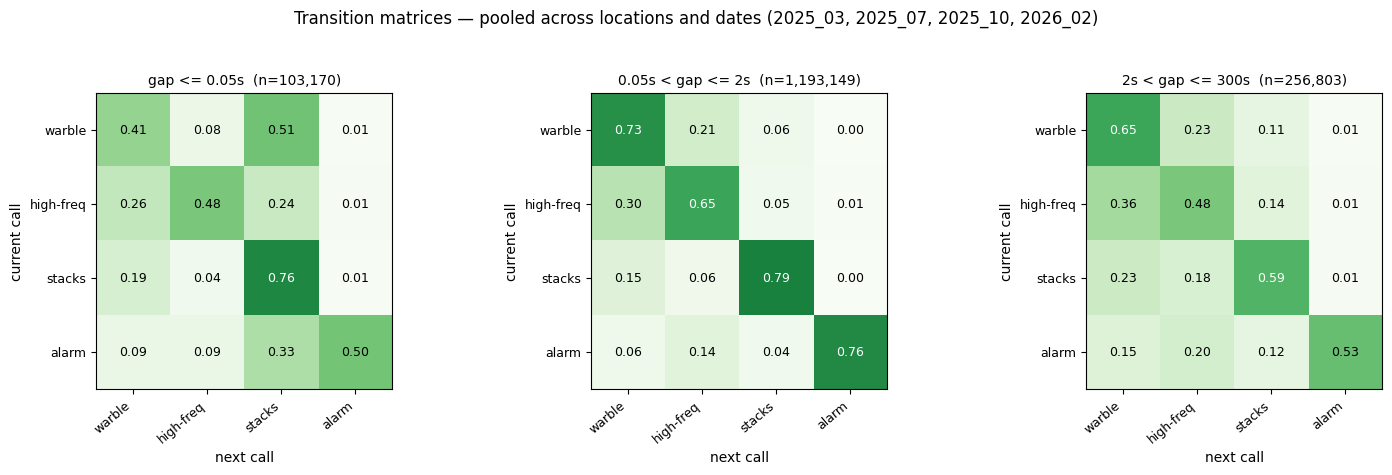

In [ ]:
# Transition matrices like scripts/run_transitions.py, but with no
# above-ground vs underground split — all channels pooled, no light/dark split.

import sys
REPO_ROOT = Path("/Users/gilyginosar/repos/gerbil_vocalization_analysis")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from vocalization_analysis.calc_transitions import compute_arena_transitions

# Same band specs as run_transitions.py.
VERY_SHORT_GAP_SEC = 0.05
SHORT_GAP_SEC      = 2
LONG_GAP_SEC       = 300
CALL_TYPE_ORDER    = ["newborn","warble", "high-freq", "stacks", "alarm"]

# Pool calls across all dates.
parts = []
for date_tag in DATES_TO_PLOT:
    parts.append(pd.read_parquet(PARQUET_DIR / f"all_calls_{date_tag}.parquet"))
calls = pd.concat(parts, ignore_index=True)

# Source key = (date, exp) — keeps transitions from spanning experiments.
exp_dfs = {f"{date}_{exp}": grp
           for (date, exp), grp in calls.groupby(["date_folder", "exp"])}

bands = [
    ("right", None,                VERY_SHORT_GAP_SEC, f"gap <= {VERY_SHORT_GAP_SEC}s"),
    ("mid",   VERY_SHORT_GAP_SEC,  SHORT_GAP_SEC,      f"{VERY_SHORT_GAP_SEC}s < gap <= {SHORT_GAP_SEC}s"),
    ("left",  SHORT_GAP_SEC,       LONG_GAP_SEC,       f"{SHORT_GAP_SEC}s < gap <= {LONG_GAP_SEC}s"),
]

# Compute matrices per band (the function returns arena + underground; we'll
# pool them ourselves to get a single matrix per band).
def compute_pooled(exp_dfs, lower, upper):
    res = compute_arena_transitions(
        exp_dfs,
        inter_call_interval_sec=upper,
        min_inter_call_interval_sec=lower,
        call_type_order=CALL_TYPE_ORDER,
    )
    counts = res["arena"]["counts"].add(res["underground"]["counts"], fill_value=0).astype(int)
    call_counts = res["arena"]["call_counts"].add(res["underground"]["call_counts"], fill_value=0).astype(int)
    probs = counts.div(counts.sum(axis=1), axis=0).fillna(0)
    return {"counts": counts, "call_counts": call_counts, "probabilities": probs}

matrices = {band: compute_pooled(exp_dfs, lower, upper) for band, lower, upper, _ in bands}

# Plot: 1 row x 3 cols (one per band), each a probability heatmap.
fig, axes = plt.subplots(1, len(bands), figsize=(5.0 * len(bands), 4.5))
if len(bands) == 1:
    axes = [axes]

for ax, (band_name, _, _, label) in zip(axes, bands):
    m = matrices[band_name]["probabilities"].values
    n_trans = int(matrices[band_name]["counts"].values.sum())

    im = ax.imshow(m, cmap="Greens", vmin=0, vmax=1)
    for i in range(len(CALL_TYPE_ORDER)):
        for j in range(len(CALL_TYPE_ORDER)):
            txt_color = "white" if m[i, j] > 0.55 else "black"
            ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center",
                    fontsize=9, color=txt_color)

    ax.set_xticks(range(len(CALL_TYPE_ORDER)))
    ax.set_xticklabels(CALL_TYPE_ORDER, rotation=40, ha="right", fontsize=9)
    ax.set_yticks(range(len(CALL_TYPE_ORDER)))
    ax.set_yticklabels(CALL_TYPE_ORDER, fontsize=9)
    ax.set_title(f"{label}  (n={n_trans:,})", fontsize=10)
    ax.set_ylabel("current call", fontsize=10)
    ax.set_xlabel("next call", fontsize=10)

fig.suptitle(f"Transition matrices — pooled across locations and dates ({', '.join(DATES_TO_PLOT)})",
             fontsize=12, y=1.04)
fig.tight_layout()
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.012, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("P(next | current)", fontsize=9)
save_fig(fig, "transition_matrices_pooled_all_locations")
plt.show()

Pre-birth (false positives): 5,404 calls
Post-birth (real):           45,908 calls


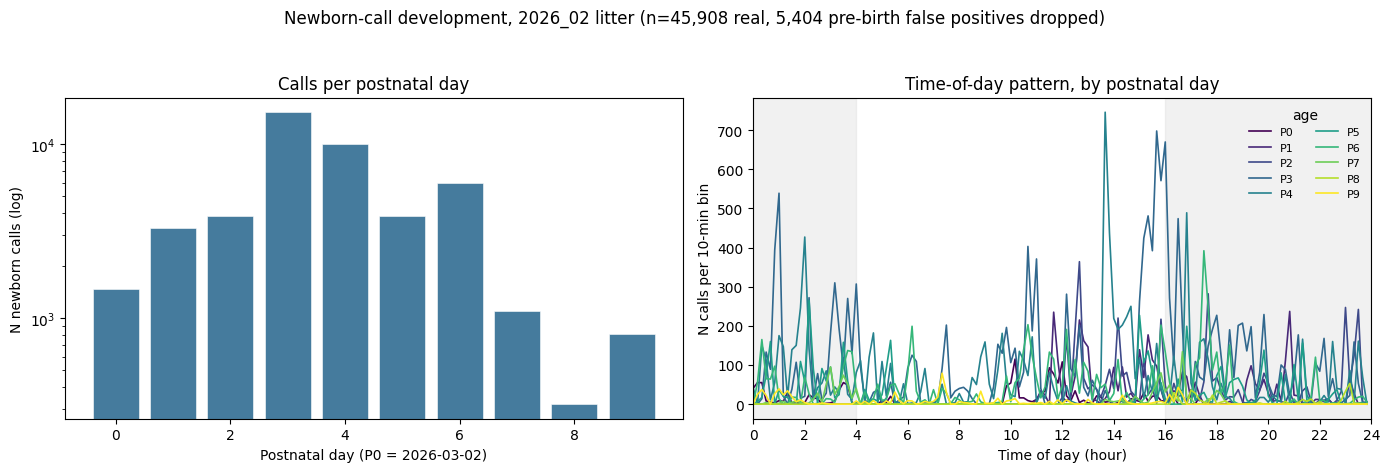

In [9]:
# Newborn-call development in 2026_02. Litter was born overnight between
# 2026-03-01 and 2026-03-02 — day_in_experiment 13 is postnatal day 0.
# Calls before then are classifier false positives and get dropped.

BIRTH_DAY_IN_EXP = 13   # 2026-03-02 = postnatal day 0
BIN_MIN          = 10   # minutes per bin for the time-of-day curve

df = pd.read_parquet(PARQUET_DIR / "all_calls_2026_02.parquet")
nb_all = df[df["event_type"] == "newborn"].copy()
nb_all["age_days"] = nb_all["day_in_experiment"] - BIRTH_DAY_IN_EXP

n_false_pos = int((nb_all["age_days"] < 0).sum())
n_real      = int((nb_all["age_days"] >= 0).sum())
print(f"Pre-birth (false positives): {n_false_pos:,} calls")
print(f"Post-birth (real):           {n_real:,} calls")

nb = nb_all[nb_all["age_days"] >= 0].copy()
ages = sorted(nb["age_days"].unique())

per_age = (
    nb.groupby("age_days")["event_type"].size()
      .rename("n_calls")
      .reindex(ages, fill_value=0)
)

# Plot ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) Calls per postnatal day.
ax = axes[0]
ax.bar(per_age.index, per_age.values, color="#457B9D", edgecolor="white", linewidth=0.4)
ax.set_yscale("log")
ax.set_xlabel("Postnatal day (P0 = 2026-03-02)")
ax.set_ylabel("N newborn calls (log)")
ax.set_title("Calls per postnatal day")

# (2) Time-of-day pattern, one line per postnatal day, BIN_MIN-min bins.
ax = axes[1]
ts = nb["start_time_real"]
nb["bin_min"] = ((ts.dt.hour * 60 + ts.dt.minute) // BIN_MIN) * BIN_MIN

cmap = plt.get_cmap("viridis")
colors = [cmap(i / max(1, len(ages) - 1)) for i in range(len(ages))]

for age, color in zip(ages, colors):
    sub = nb[nb["age_days"] == age]
    counts = sub.groupby("bin_min").size()
    counts = counts.reindex(np.arange(0, 24 * 60, BIN_MIN), fill_value=0)
    ax.plot(counts.index / 60, counts.values, color=color, linewidth=1.2,
            label=f"P{int(age)}")

LIGHT_START, LIGHT_END = LIGHT_OVERRIDES.get("2026_02", LIGHT_DEFAULT)
if LIGHT_START < LIGHT_END:
    ax.axvspan(0, LIGHT_START, color="lightgray", alpha=0.3, zorder=0)
    ax.axvspan(LIGHT_END, 24,   color="lightgray", alpha=0.3, zorder=0)
else:
    ax.axvspan(LIGHT_END, LIGHT_START, color="lightgray", alpha=0.3, zorder=0)

ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_xlabel("Time of day (hour)")
ax.set_ylabel(f"N calls per {BIN_MIN}-min bin")
ax.set_title("Time-of-day pattern, by postnatal day")
ax.legend(fontsize=8, ncol=2, loc="upper right", title="age", frameon=False)

fig.suptitle(
    f"Newborn-call development, 2026_02 litter "
    f"(n={n_real:,} real, {n_false_pos:,} pre-birth false positives dropped)",
    fontsize=12, y=1.04,
)
fig.tight_layout()
save_fig(fig, "newborn_development_2026_02")
plt.show()